# Step-dependent slicing algorithm

Based on this paper: Lykov et al. — Tensor Network Quantum Simulator With Step-Dependent Parallelization

1. Import modules

In [1]:
from graph import *
from plots import *
from ordering import *
from conversion import *
import networkx as nx

2. Create a 3-regular graph and draw it

Number of nodes: 20
Number of edges: 30


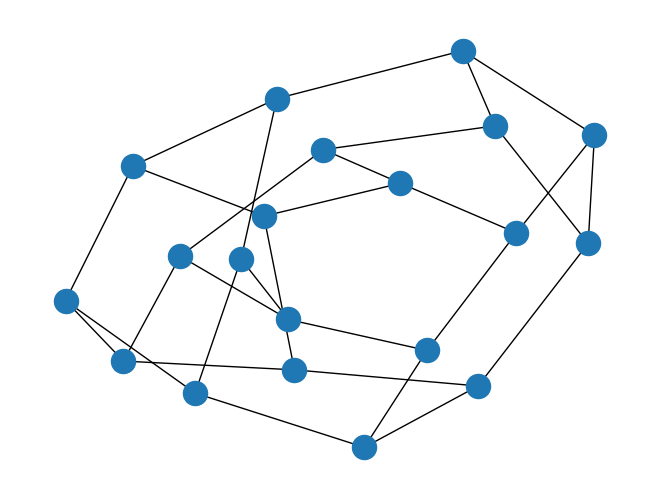

In [3]:
G = createGraph(20)
nx.draw(G)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

3. Convert graph to a QAOA circuit and draw the circuit

Number of gates: 71


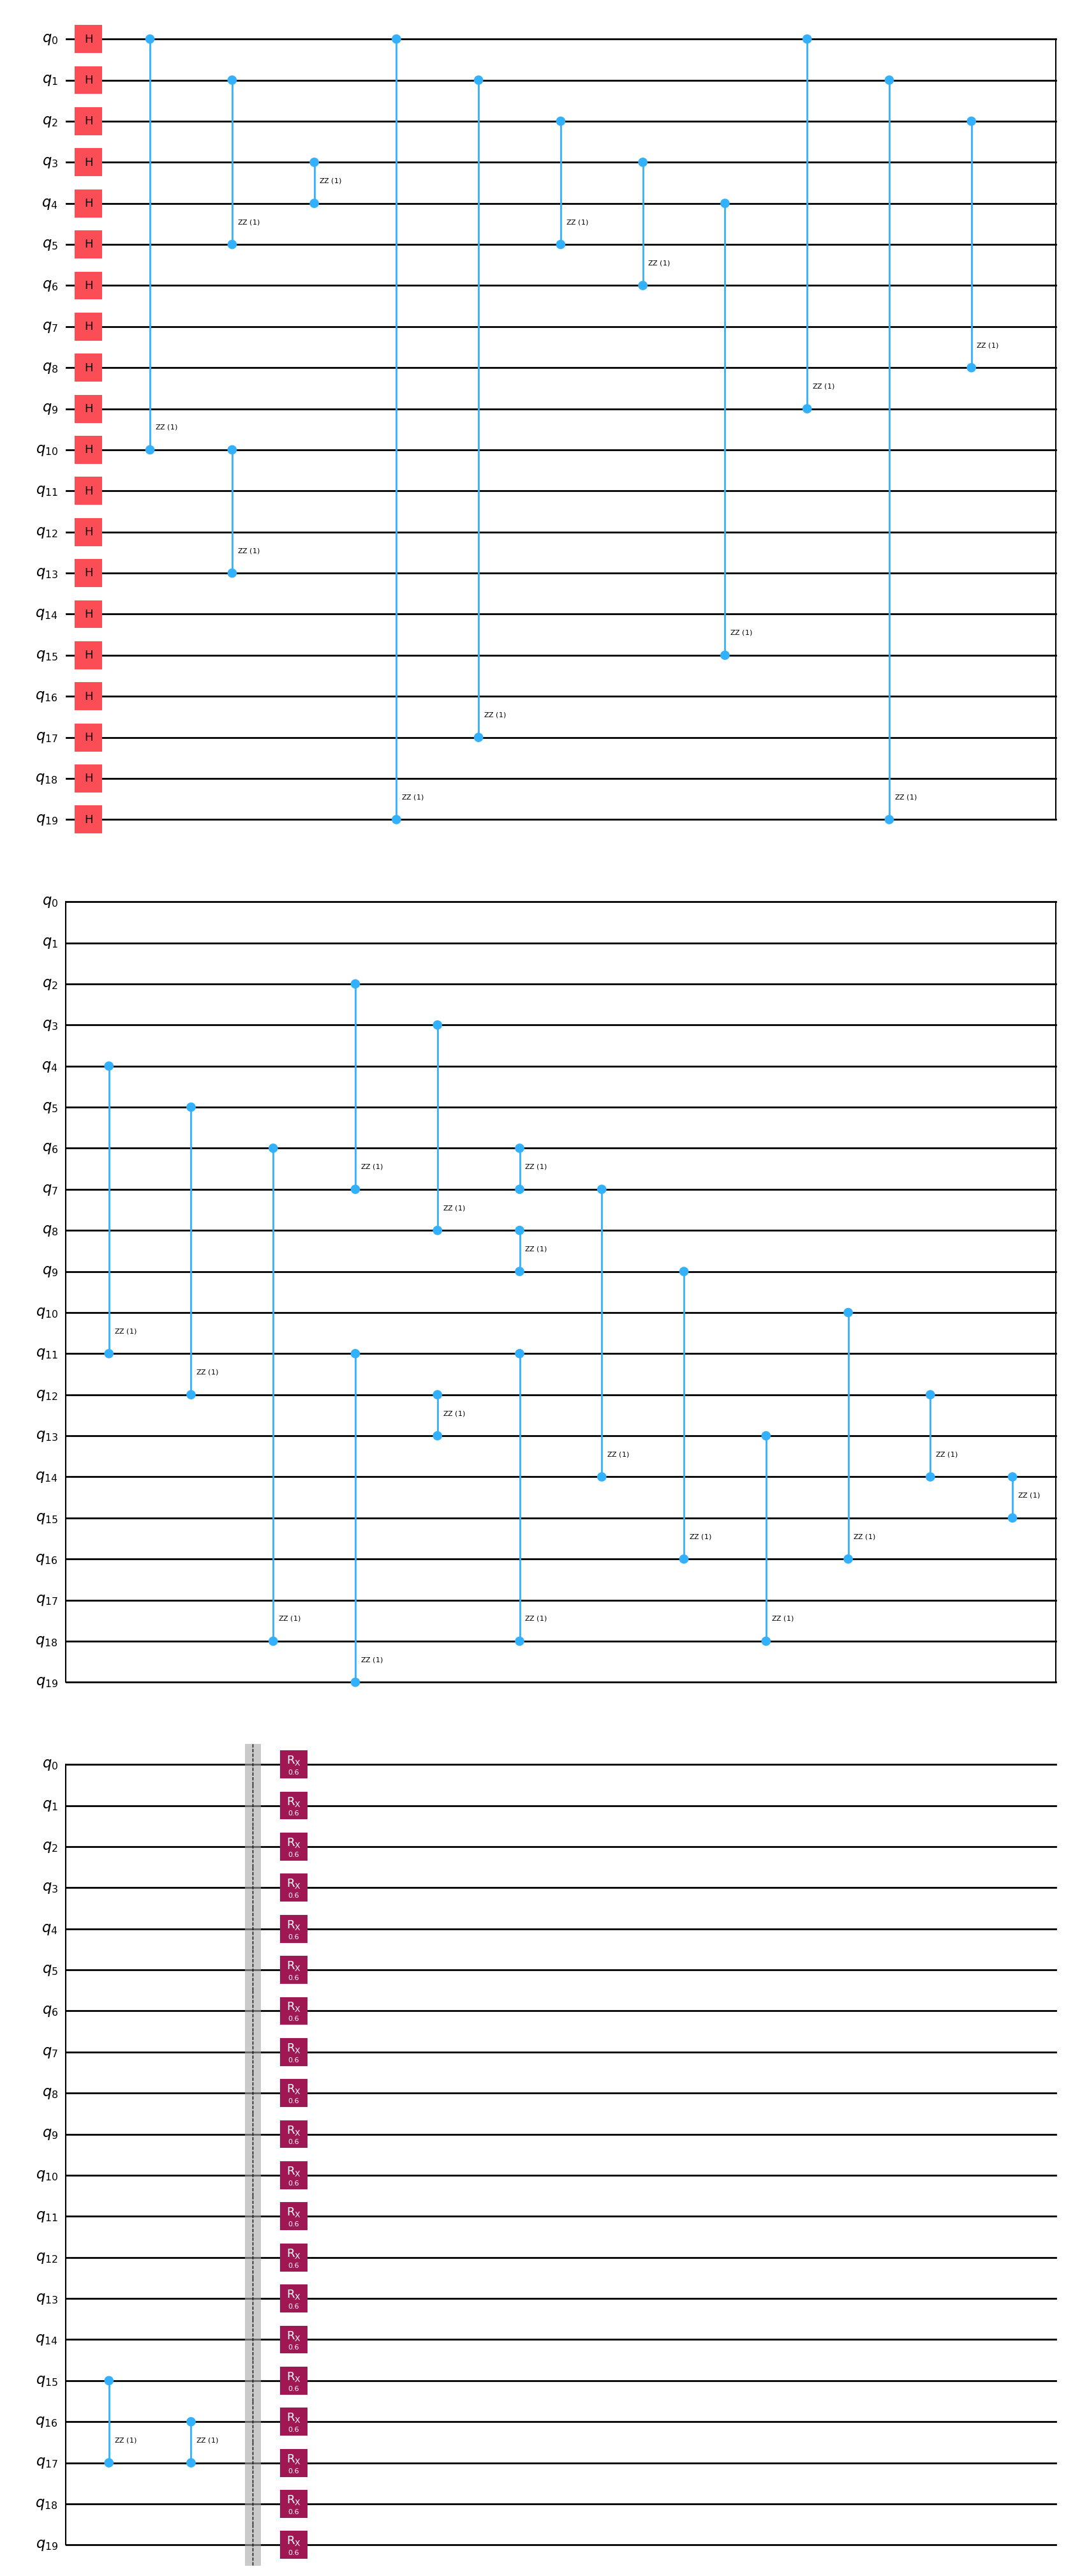

In [14]:
circuit = convertToCircuit(G)
print(f"Number of gates: {len(circuit.data)}")
circuit.draw('mpl', fold=24)

4. Convert the circuit to line graph representation and draw it

Number of nodes: 90
Number of edges: 130


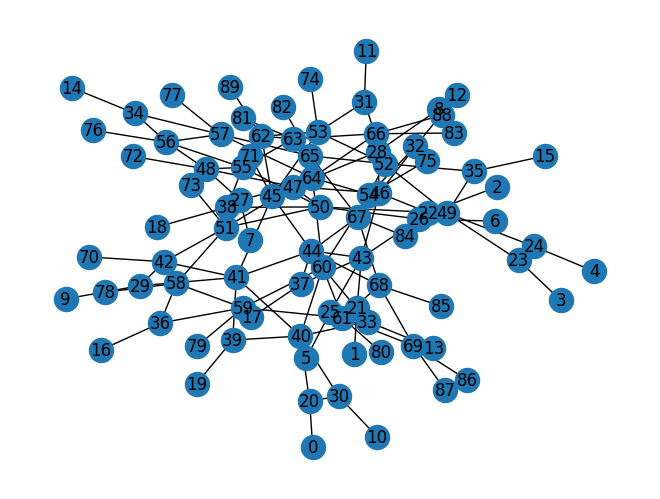

In [15]:
LG = convertToLineGraph(circuit)
nx.draw(LG, with_labels=True)
print(f"Number of nodes: {LG.number_of_nodes()}")
print(f"Number of edges: {LG.number_of_edges()}")

5. Find initial ordering with rgreedy
6. Run step-dependent slicing with n = 1, r = 1, i.e. finding the optimal step S for slicing 1 node

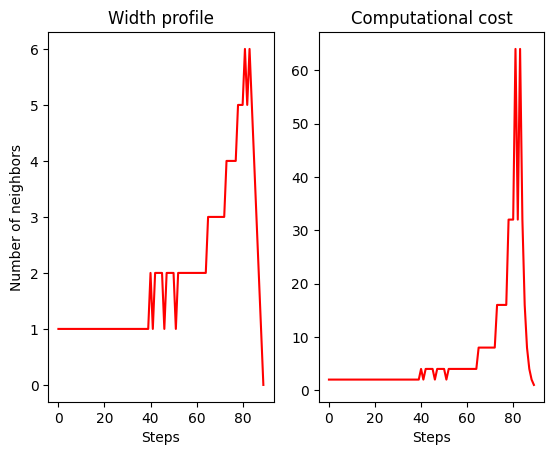

In [16]:
order, widths, width = rgreedy(LG, 0.02, 200)
schedule, newWidths, newWidth = stepDependentSlicing(LG, order, widths)
plotNeighbors(widths)

7. Compare the contraction width and computational cost before vs. after slicing

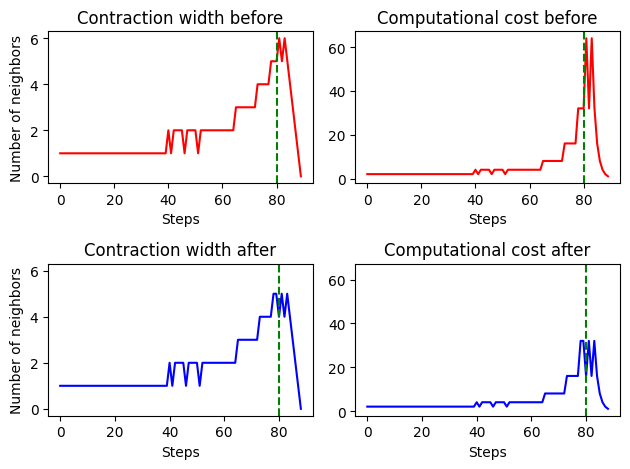

Contraction width was 6 now it's 5 with optimal step S = 80
Computational cost was 64, now it's 32 which is a reduction of 2
{80: [67]}


In [17]:
plotComparison(widths, newWidths, schedule)
print(f"Contraction width was {width} now it's {newWidth} with optimal step S = {list(schedule.keys())[0]}")
print(f"Computational cost was {int(math.exp2(width))}, now it's {int(math.exp2(newWidth))} which is a reduction of {int(math.exp2(width)/math.exp2(newWidth))}")
print(schedule)